In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns 

from sklearn import tree 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [15]:
# Load dataset
df = pd.read_csv("./titanic/train.csv")

In [16]:
# Data preprocessing
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df, columns=["Sex","Embarked"], drop_first=True)
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True


In [17]:
# Feature selection
features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex_male", "Embarked_Q", "Embarked_S"]
x = df[features]
y = df["Survived"]

In [18]:
# Train/validation split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=50)

In [19]:
# Try shallow tree 
model_depth_shallow = tree.DecisionTreeClassifier(max_depth=2, random_state=50) 
model_depth_shallow.fit(x_train, y_train) 
pred_shallow = model_depth_shallow.predict(x_val) 
acc_shallow = accuracy_score(y_val, pred_shallow)

print(f"Depth = 2 → Accuracy: {acc_shallow:.4f}")

Depth = 2 → Accuracy: 0.7318


In [20]:
# Try deeper tree 
model_depth_deep = tree.DecisionTreeClassifier(max_depth=6, random_state=50) 
model_depth_deep.fit(x_train, y_train) 
pred_deep = model_depth_deep.predict(x_val) 
acc_deep = accuracy_score(y_val, pred_deep)

print(f"Depth = 6 → Accuracy: {acc_deep:.4f}")

Depth = 6 → Accuracy: 0.7765


In [21]:
# Experiment: tree depth
depths = range(1, 11) 
train_acc = [] 
val_acc = [] 

for d in depths: 
    model = tree.DecisionTreeClassifier(max_depth=d, random_state=50) 
    model.fit(x_train, y_train) 

    y_train_pred = model.predict(x_train) 
    y_val_pred = model.predict(x_val) 
    
    train_acc.append(accuracy_score(y_train, y_train_pred)) 
    val_acc.append(accuracy_score(y_val, y_val_pred))

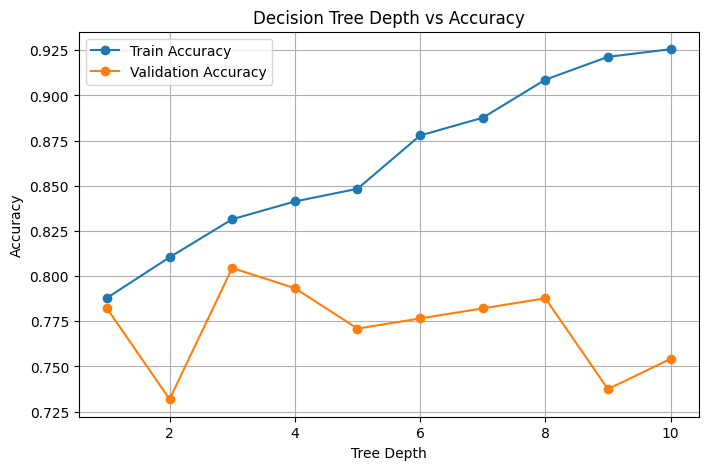

In [22]:
# Results
plt.figure(figsize=(8, 5)) 
plt.plot(depths, train_acc, marker='o', label="Train Accuracy") 
plt.plot(depths, val_acc, marker='o', label="Validation Accuracy") 
plt.xlabel("Tree Depth") 
plt.ylabel("Accuracy") 
plt.title("Decision Tree Depth vs Accuracy") 
plt.legend() 
plt.grid() 
plt.show()

In [23]:
# Select best depth 
best_depth = depths[np.argmax(val_acc)] 
print(f"Best depth: {best_depth}")

Best depth: 3


In [24]:
# Train final model 
model = tree.DecisionTreeClassifier(max_depth=best_depth, random_state=50) 
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",50
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

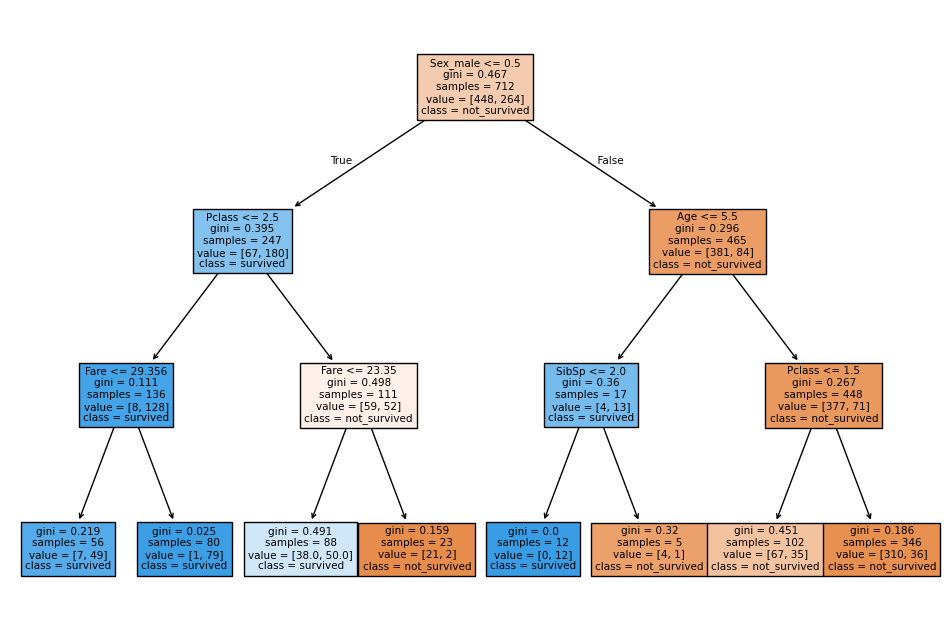

In [25]:
# Visualize tree 
plt.figure(figsize=(12, 8)) 
tree.plot_tree( model, feature_names=features, class_names=["not_survived", "survived"], filled=True ) 
plt.show()

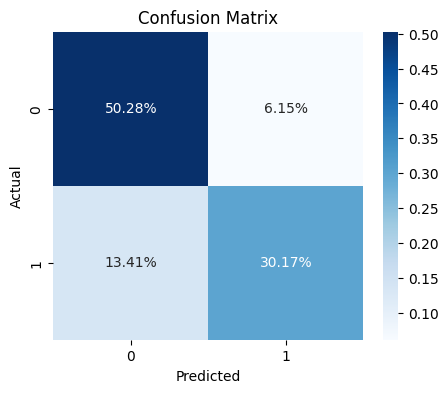

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       101
           1       0.83      0.69      0.76        78

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.80      0.80       179



In [26]:
# Evaluation 
y_pred = model.predict(x_val) 
cf_matrix = confusion_matrix(y_val, y_pred) 
plt.figure(figsize=(5, 4)) 

sns.heatmap(cf_matrix / np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues') 
plt.title("Confusion Matrix") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show() 
print(classification_report(y_val, y_pred))